<div dir="rtl" style="text-align: right; line-height: 1.9; font-family: 'Segoe UI', Tahoma, Arial, sans-serif; font-size: 16px;">

**[🡨 بازگشت به فصل دوم (محاسبات بازده)](Fasl_2_Masterclass.ipynb)**

# 🎓 مسترکلاس مهندسی مالی تصادفی با پایتون
## فصل ۳: توزیع‌های احتمال، توابع مشخصه و برآورد پارامتر (Probability, CF & Parameter Estimation)

---
### 🎯 هدف این نوت‌بوک
در فصل قبل آموختیم که قیمت‌های خام بازار را به بازده‌های ایستا (Stationary Returns) تبدیل کنیم. اما یک تحلیلگر کمی (Quant) برای ساخت مدل‌های تصادفی مانند بلک-شولز یا شبیه‌سازی مونت‌کارلو، باید رفتار آماری این بازده‌ها را مدل‌سازی کند.

در این فصل ما از توابع توزیع احتمال عبور کرده و وارد ابزارهای پیشرفته‌تر می‌شویم:
1. **توابع مشخصه (Characteristic Functions):** تبدیل توزیع‌ها به فضای مختلط با استفاده از تبدیل فوریه.
2. **حداکثر درستی‌نمایی (MLE):** یافتن پارامترهای بهینه توزیع با استفاده از بهینه‌سازی توابع هدف.
3. **استنتاج بیزی (Bayesian Inference):** یادگیری و آپدیت پیوسته باورها با دریافت جریان‌های جدید داده از بازار.

### 📚 بخش ۱: آماده‌سازی محیط و توابع کمکی
ابتدا کتابخانه‌های آماری (`scipy.stats`) و کلاس دریافت داده را که از فصول قبل نیاز داریم بارگذاری می‌کنیم.

</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import binom, beta, poisson, norm, expon, uniform
from abc import ABC, abstractmethod
from typing import TypedDict, List, Dict, Any

# --- Minimal Data Adapter (Carried from Chapter 1 & 2 for completeness) ---
class YahooFinancialsAdapter:
    """Minimal adapter to fetch real market data for our statistical tests"""
    def __init__(self, ticker="AAPL", training_set_date_range=("2021-01-01", "2022-06-30")):
        self.ticker = ticker
        self.start, self.end = training_set_date_range

    @property
    def training_set(self):
        data = yf.download(self.ticker, start=self.start, end=self.end, progress=False)
        return pd.DataFrame({"time": data.index, "stock price": data['Close'].values.flatten()})

print("\n--- Setup Complete! Libraries and Data Adapters are loaded. ---")


--- Setup Complete! Libraries and Data Adapters are loaded. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۲: توزیع‌های گسسته در برابر پیوسته (PMF vs PDF)

در مهندسی مالی، ما با دو نوع متغیر تصادفی روبرو هستیم:
1. **گسسته (Discrete):** با تابع جرم احتمال (PMF) مدل می‌شود. مانند مدل‌سازی **تعداد پرش‌ها (Jumps)** یا شوک‌های ناگهانی بازار با استفاده از توزیع پواسون یا دوجمله‌ای.
2. **پیوسته (Continuous):** با تابع چگالی احتمال (PDF) مدل می‌شود. مانند قیمت سهام یا بازده‌ها که در قالب اعداد حقیقی پیوسته نوسان می‌کنند.

در بلوک زیر، تفاوت ماهوی PMF (که روی نقاط خاص مقدار دارد) و PDF (که مساحت زیر نمودار آن، یا همان انتگرال، نشان‌دهنده احتمال است) را مصورسازی می‌کنیم.

</div>

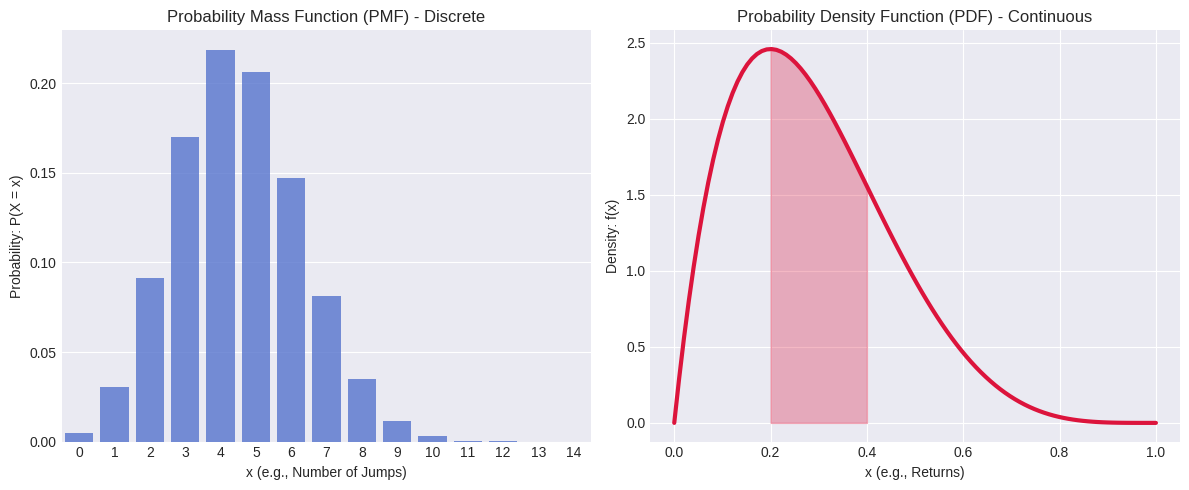

In [ ]:
# --- PMF vs PDF Visualization (Adapted from dist_shapes.py) ---
def plot_pmf_and_pdf():
    plt.style.use("seaborn-v0_8-darkgrid")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Discrete Distribution (Binomial PMF)
    x_pmf = np.arange(0, 15)
    # Probability of x successes in 15 trials with p=0.3
    sns.barplot(ax=ax[0], x=x_pmf, y=binom(15, 0.3).pmf(x_pmf), color='royalblue', alpha=0.8)
    ax[0].set_title('Probability Mass Function (PMF) - Discrete')
    ax[0].set_xlabel('x (e.g., Number of Jumps)')
    ax[0].set_ylabel('Probability: P(X = x)')

    # 2. Continuous Distribution (Beta PDF)
    x_pdf = np.linspace(start=0, stop=1, num=100)
    beta_rv = beta(a=2, b=5)
    sns.lineplot(ax=ax[1], x=x_pdf, y=beta_rv.pdf(x=x_pdf), lw=3, color='crimson')

    # The probability in continuous space is the area under the curve (integral)
    x_fill = np.linspace(0.2, 0.4, 50)
    ax[1].fill_between(x=x_fill, y1=beta_rv.pdf(x=x_fill), color='crimson', alpha=0.3)
    ax[1].set_title('Probability Density Function (PDF) - Continuous')
    ax[1].set_xlabel('x (e.g., Returns)')
    ax[1].set_ylabel('Density: f(x)')

    fig.tight_layout()
    plt.show()

plot_pmf_and_pdf()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۳: توابع مشخصه (Characteristic Functions - CF)

یکی از قدرتمندترین ابزارها در مهندسی مالی پیشرفته (مانند مدل Heston یا قیمت‌گذاری آپشن‌ها با استفاده از تبدیلات فوریه) **تابع مشخصه** است.
بسیاری از فرآیندهای تصادفی مالی فرمول بسته و مشخصی برای تابع چگالی احتمال ($f(x)$) ندارند، اما تابع مشخصه آن‌ها همواره وجود دارد. تابع مشخصه در واقع تبدیل فوریه توزیع احتمال در فضای اعداد مختلط (Complex Plane) است:

$$ \phi(\omega) = \mathbb{E}[e^{i\omega X}] = \int_{-\infty}^{\infty} e^{i\omega x} f(x)dx $$

که در آن $i$ عدد موهومی ($i = \sqrt{-1}$) و $\omega$ فرکانس است. در پایتون عدد موهومی با `1j` نمایش داده می‌شود. در بلوک زیر توابع مشخصه برای توزیع‌های گوسی (نرمال)، یکنواخت، نمایی و پواسون استخراج و بخش حقیقی (Real Part) آن‌ها رسم می‌شود.

</div>

Plotting the Real Part of Characteristic Functions:


/tmp/ipykernel_774/2523932251.py:40: UserWarning: Glyph 981 (\N{GREEK PHI SYMBOL}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 981 (\N{GREEK PHI SYMBOL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


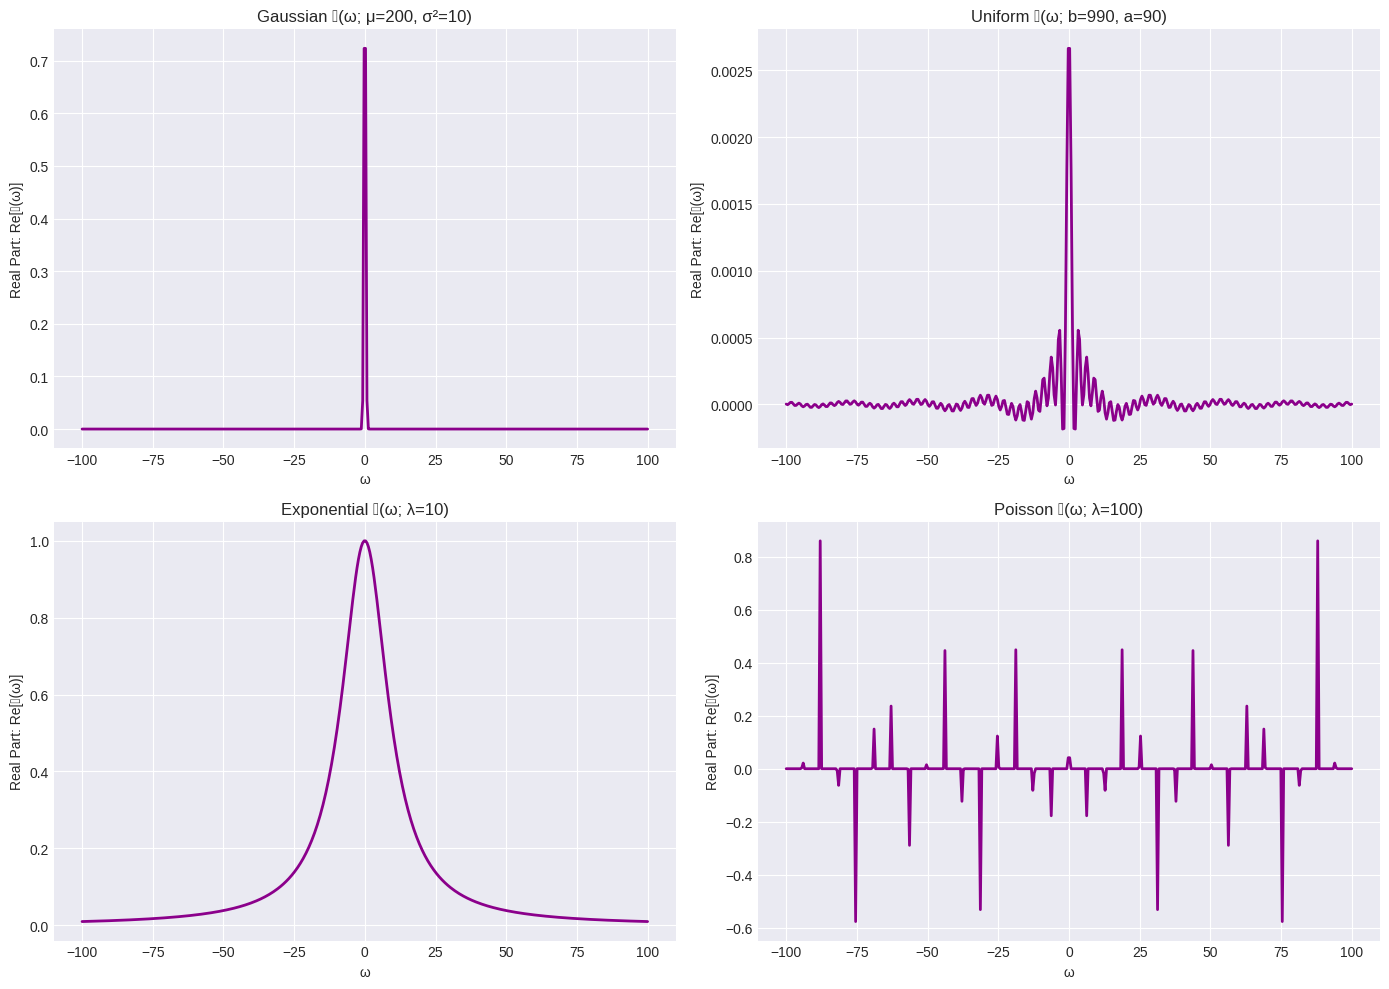

In [ ]:
# --- Characteristic Functions Engine (distributions.py & visualization.py) ---
def plot_characteristic_functions():
    # Frequency domain from -100 to 100
    ω_arr = np.linspace(start=-100, stop=100, num=400)

    # Mathematical formulation of CFs (Mapping math to Python with 1j)
    def _ϕ_gaussian(ω, μ=200, σ2=10):
        return np.exp((μ * ω * 1j) - (0.5 * ω * ω * σ2))

    def _ϕ_uniform(ω, b=990, a=90):
        # Handle division by zero warning at w=0 implicitly by returning 1
        return np.where(ω==0, 1+0j, (np.exp(1j * ω * b) - np.exp(1j * ω * a)) / (1j * ω * (b - a)))

    def _ϕ_exponential(ω, λ=10.0):
        return 1.0 / (1.0 - ((ω * 1j) / λ))

    def _ϕ_poisson(ω, λ=100):
        return np.exp(λ * (np.exp(1j * ω) - 1))

    # Generate dataframes containing the Real part of the complex numbers
    def _gen_df(func, name):
        return pd.DataFrame({'ω': ω_arr, 'ϕ(ω)': func(ω_arr).real})

    cfs = {
        'Gaussian ϕ(ω; μ=200, σ²=10)': _gen_df(_ϕ_gaussian, 'Gaussian'),
        'Uniform ϕ(ω; b=990, a=90)': _gen_df(_ϕ_uniform, 'Uniform'),
        'Exponential ϕ(ω; λ=10)': _gen_df(_ϕ_exponential, 'Exponential'),
        'Poisson ϕ(ω; λ=100)': _gen_df(_ϕ_poisson, 'Poisson')
    }

    # Visualization
    plt.style.use("seaborn-v0_8-darkgrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, (title, df) in zip(axes.flatten(), cfs.items()):
        sns.lineplot(ax=ax, data=df, x='ω', y='ϕ(ω)', lw=2, color='darkmagenta')
        ax.set_title(title, fontsize=12)
        ax.set_ylabel("Real Part: Re[ϕ(ω)]")

    fig.tight_layout()
    plt.show()

print("Plotting the Real Part of Characteristic Functions:")
plot_characteristic_functions()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۴: برآورد پارامتر با حداکثر درستی‌نمایی (Maximum Likelihood Estimation - MLE)

فرض کنید داده‌های بازار (مانند بازده سهام) را در اختیار داریم و می‌دانیم که توزیع آن‌ها تقریباً نرمال است. اما میانگین ($\mu$) و واریانس ($\sigma^2$) واقعی جامعه چیست؟

ما باید پارامترهایی ($\theta$) را بیابیم که **احتمال تولید شدن این داده‌ها را به حداکثر برسانند**. تابع درستی‌نمایی حاصل‌ضرب احتمالات است، اما از آنجا که ضرب اعداد کوچک به خطای Underflow کامپیوتری منجر می‌شود، ما از لگاریتم آن استفاده می‌کنیم (Log-Likelihood):

$$ \ell(\theta | X) = \sum_{i=1}^n \log f(x_i | \theta) $$

در کدهای این بخش، نویسنده با استفاده از `np.meshgrid` یک فضای جستجوی سه‌بعدی ساخته و لگاریتم درستی‌نمایی را روی آن ترسیم می‌کند. نقطه اوج (قله) این کوه سه‌بعدی، پارامترهای بهینه ما هستند.

</div>

Fetching data and computing MLE surfaces...


/tmp/ipykernel_774/1933105394.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.ticker, start=self.start, end=self.end, progress=False)
/tmp/ipykernel_774/1933105394.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.ticker, start=self.start, end=self.end, progress=False)


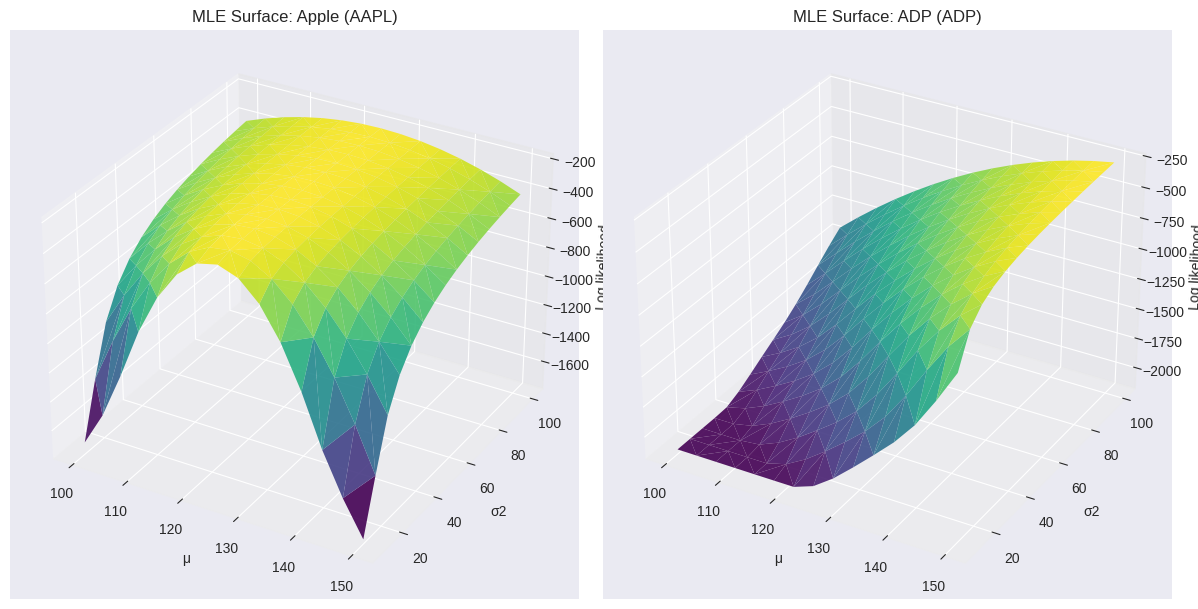

In [ ]:
# --- Log-Likelihood Estimation Engine (estimation.py) ---

class LogLikelihoodFunctionAnalysis(ABC):
    """
    Base architecture to study and optimize Log-Likelihood for any distribution.
    """
    class Dataset(TypedDict):
        source: str
        x: List

    def __init__(self, θ_sets: Dict[str, List], datasets: List[Dataset]):
        self._θ_sets = θ_sets
        self._datasets = datasets
        self._total_loglikelihood = self._compute_total_loglikelihood()
        self._max_loglikelihood_details = self._get_max_loglikelihoods()

    @abstractmethod
    def _compute_likelihood(self, x, **θ):
        ...

    def _prepare_combibnations_for_θ(self) -> Dict[str, List]:
        # Creates an N-dimensional grid for hyperparameter search
        θ_grid = None
        θ_name_grid_index = {}
        for i, (θ_name, θ_val) in enumerate(self._θ_sets.items()):
            if i == 0:
                θ_grid = np.meshgrid(θ_val)
            else:
                θ_grid = np.meshgrid(θ_grid, θ_val)
            θ_name_grid_index[θ_name] = i

        return {name: θ_grid[idx].flatten() for name, idx in θ_name_grid_index.items()}

    def get_loglikelihood_for_observations(self, x, **θ):
        # Mathematical Log-Likelihood formula: Sum of log(PDF)
        return np.sum(np.log(self._compute_likelihood(x, **θ) + 1e-15)) # added epsilon for numerical stability

    def _compute_total_loglikelihood(self):
        total_llh = {}
        θ_combs = self._prepare_combibnations_for_θ()
        num_θ_values = len(list(θ_combs.values())[0])

        for ds in self._datasets:
            llh = []
            for i in range(num_θ_values):
                current_params = {k: v[i] for k, v in θ_combs.items()}
                score = self.get_loglikelihood_for_observations(ds["x"], **current_params)
                llh.append((current_params, score))
            total_llh[ds["source"]] = llh
        return total_llh

    def _get_max_loglikelihoods(self):
        # Finds the argmax of the likelihood function
        return {k: max(v, key=lambda t: t[1]) for k, v in self._total_loglikelihood.items()}

    def plot_3d_surface(self, θ_names: List[str]):
        # 3D visualization using matplotlib
        fig = plt.figure(figsize=(12, 6))

        for idx, (source, liklihood_details) in enumerate(self._total_loglikelihood.items(), 1):
            ax = fig.add_subplot(1, len(self._total_loglikelihood), idx, projection="3d")
            t_arr = np.array(liklihood_details, dtype=object)
            θ_name_val_df = pd.DataFrame.from_records(t_arr[:, 0])

            ax.plot_trisurf(
                θ_name_val_df[θ_names[0]],
                θ_name_val_df[θ_names[1]],
                list(t_arr[:, 1]),
                cmap=plt.cm.viridis, edgecolor="none", alpha=0.9
            )
            ax.set_xlabel(θ_names[0])
            ax.set_ylabel(θ_names[1])
            ax.set_zlabel("Log likelihood")
            ax.set_title(f"MLE Surface: {source}")

        fig.tight_layout()
        plt.show()

class GaussianLogLikelihoodFunctionAnalysis(LogLikelihoodFunctionAnalysis):
    def _compute_likelihood(self, x, μ, σ2):
        return norm.pdf(x, loc=μ, scale=np.sqrt(σ2))

# --- Testing MLE on Market Data ---
def test_gaussian_mle():
    print("Fetching data and computing MLE surfaces...")
    datasets = [
        {"source": "Apple (AAPL)", "x": YahooFinancialsAdapter(ticker="AAPL", training_set_date_range=("2021-02-01", "2021-04-30")).training_set["stock price"]},
        {"source": "ADP (ADP)", "x": YahooFinancialsAdapter(ticker="ADP", training_set_date_range=("2021-02-01", "2021-04-30")).training_set["stock price"]}
    ]

    θ_sets = {
        "μ": np.linspace(100.0, 150.0, 15),
        "σ2": np.linspace(10.0, 100.0, 15),
    }

    analysis = GaussianLogLikelihoodFunctionAnalysis(θ_sets=θ_sets, datasets=datasets)
    analysis.plot_3d_surface(θ_names=["μ", "σ2"])

test_gaussian_mle()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۵: استنتاج بیزی در بازارهای مالی (Bayesian Inference)

برخلاف روش MLE که کل داده‌ها را ثابت فرض می‌کند، استنتاج بیزی برای معاملات الگوریتمی (Algo-Trading) فوق‌العاده است؛ زیرا به ما اجازه می‌دهد باور خود را تیک-به-تیک و با دریافت اطلاعات جدید آپدیت کنیم.

ما فرض می‌کنیم داده‌ها نرمال هستند (واریانس $\sigma^2$ معلوم است) و باور ما در مورد میانگین بازار نیز نرمال است ($\mu \sim \mathcal{N}(\alpha, \beta^2)$). به این حالت **پیشین مزدوج (Conjugate Prior)** می‌گویند. قوانین آپدیت ریاضی پس از مشاهده هر قیمت $x_i$ به شرح زیر است:

$$ \beta_{new}^2 = \frac{\beta_{old}^2 \sigma^2}{\beta_{old}^2 + \sigma^2} $$
$$ \alpha_{new} = \beta_{new}^2 \left( \frac{x_i}{\sigma^2} + \frac{\alpha_{old}}{\beta_{old}^2} \right) $$

در کد زیر، ما با چهار "باور اولیه" (Prior) متفاوت شروع می‌کنیم تا ببینیم چگونه مدل پس از مشاهده قیمت‌های اپل، به سمت واقعیت همگرا می‌شود (Posterior).

</div>

Running Sequential Bayesian Learning on AAPL...
Notice how all scenarios converge to the same posterior despite different priors!


/tmp/ipykernel_774/1933105394.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.ticker, start=self.start, end=self.end, progress=False)


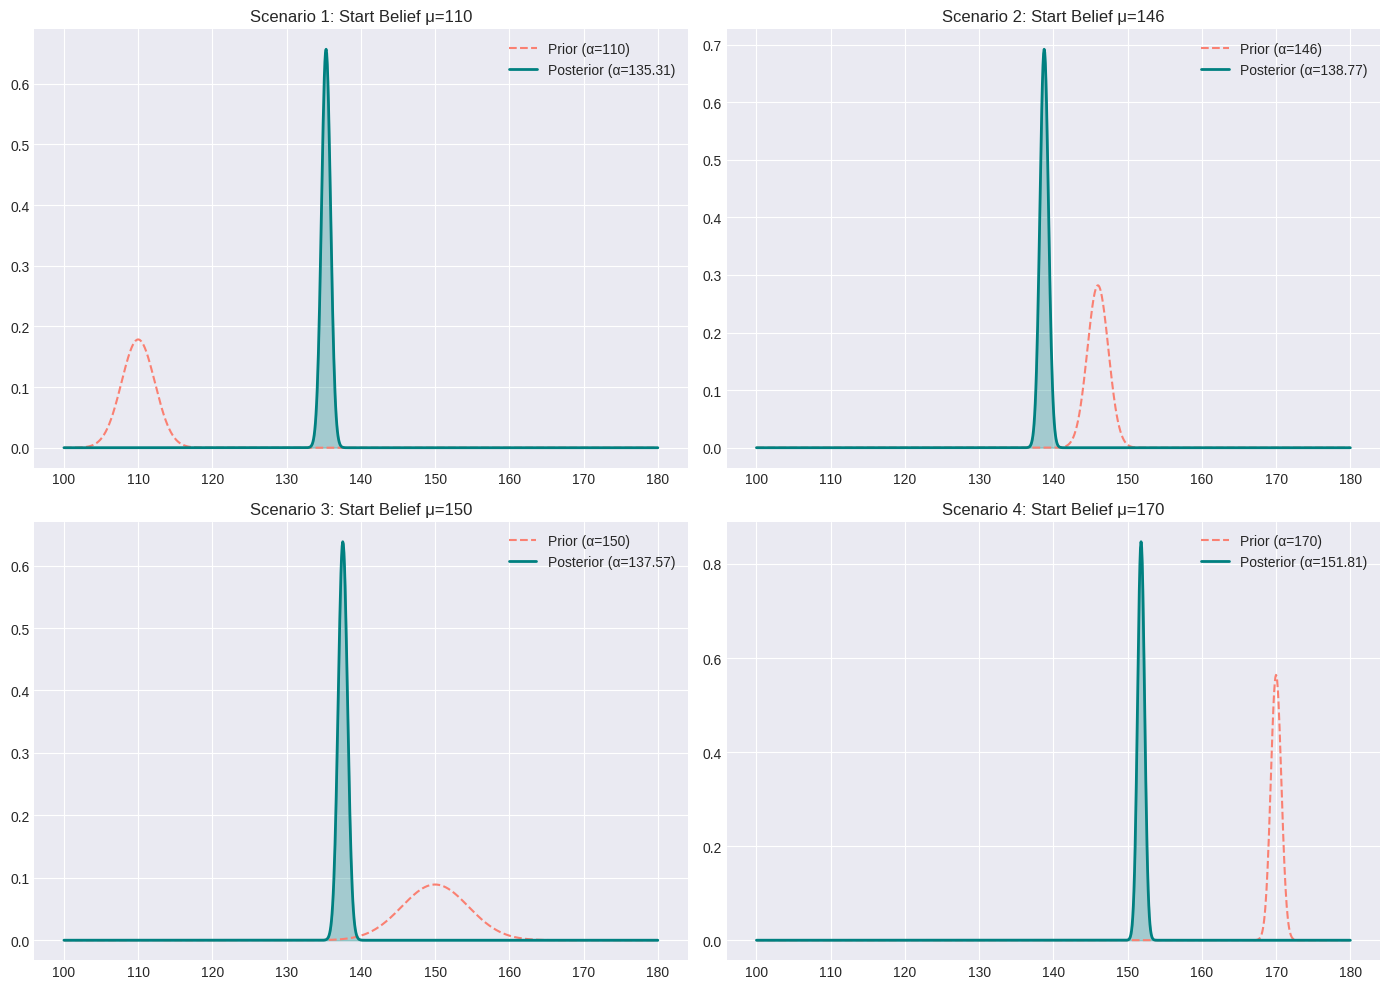

In [ ]:
# --- Bayesian Update Engine (estimation.py) ---

def iterative_gaussian_gaussian_bayesian_estimation_with_prior(x, prior_α, prior_β_2, σ2):
    """
    Bayesian belief update algorithm for Gaussian-Gaussian settings.
    Updates iteratively for streaming data.
    """
    temp_prior_α = prior_α
    temp_prior_β_2 = prior_β_2
    posterior_α = prior_α
    posterior_β_2 = prior_β_2

    for x_i in x:
        # Precision update
        posterior_β_2 = (temp_prior_β_2 * σ2) / (temp_prior_β_2 + σ2)
        # Mean update (weighted average of new data and old belief)
        posterior_α = posterior_β_2 * ((x_i / σ2) + (temp_prior_α / temp_prior_β_2))

        # Update state for next tick
        temp_prior_β_2 = posterior_β_2
        temp_prior_α = posterior_α

    # Prepare visualization data
    x_range = np.linspace(100, 180, 1000)
    prob_x = {
        "Prior": (x_range, norm.pdf(x_range, loc=prior_α, scale=np.sqrt(prior_β_2))),
        "Posterior": (x_range, norm.pdf(x_range, loc=posterior_α, scale=np.sqrt(posterior_β_2)))
    }
    return prob_x, prior_α, posterior_α

def bayesian_estimation_plot(prob_x_arr):
    plt.style.use("seaborn-v0_8-darkgrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for idx, (ax, (prob_data, prior_mean, post_mean)) in enumerate(zip(axes.flatten(), prob_x_arr)):
        # Plot Prior
        ax.plot(prob_data['Prior'][0], prob_data['Prior'][1], label=f'Prior (α={prior_mean})', color='salmon', linestyle='--')
        # Plot Posterior
        ax.plot(prob_data['Posterior'][0], prob_data['Posterior'][1], label=f'Posterior (α={post_mean:.2f})', color='teal', lw=2)
        ax.fill_between(prob_data['Posterior'][0], prob_data['Posterior'][1], color='teal', alpha=0.3)

        ax.set_title(f'Scenario {idx+1}: Start Belief μ={prior_mean}')
        ax.legend()

    fig.tight_layout()
    plt.show()

# Execute Bayesian Testing
def test_bayesian():
    print("Running Sequential Bayesian Learning on AAPL...\nNotice how all scenarios converge to the same posterior despite different priors!")
    x = YahooFinancialsAdapter(ticker="AAPL", training_set_date_range=("2021-01-01", "2021-12-31")).training_set['stock price']
    σ2 = 100 # Market volatility (known constant)

    prob_x_arr = [
        iterative_gaussian_gaussian_bayesian_estimation_with_prior(x=x, prior_α=110, prior_β_2=5, σ2=σ2),
        iterative_gaussian_gaussian_bayesian_estimation_with_prior(x=x, prior_α=146, prior_β_2=2, σ2=σ2),
        iterative_gaussian_gaussian_bayesian_estimation_with_prior(x=x, prior_α=150, prior_β_2=20, σ2=σ2),
        iterative_gaussian_gaussian_bayesian_estimation_with_prior(x=x, prior_α=170, prior_β_2=0.5, σ2=σ2),
    ]
    bayesian_estimation_plot(prob_x_arr)

test_bayesian()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

---
### 🏁 نتیجه‌گیری فصل ۳
در نمودارهای پایانی مشاهده کردید که فرآیند بیزی چگونه عمل می‌کند: اگرچه تحلیلگران مختلف با باورهای (Prior) کاملاً متفاوت و نامعتبر وارد بازار شدند (نمودارهای نقطه‌چین)، اما پس از مشاهده داده‌های واقعی بازار (Evidence)، توزیع پسین (Posterior - نمودار سبز توپر) برای همه آن‌ها به یک نقطه واحد با اطمینان بسیار بالا (واریانس کم) همگرا شد.

این مفاهیم، هسته اصلی مدل‌های یادگیری ماشین و معاملات فرکانس بالا (HFT) در مهندسی مالی را تشکیل می‌دهند.

</div>